<a href="https://colab.research.google.com/github/jeevaprakash-S/24ADI003_24BAD048/blob/main/Exp_9_scenario1_user_based_cf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

print('24BAD048 - JEEVAPRAKASH S')

24BAD048 - JEEVAPRAKASH S


## Step 2: Load the MovieLens Dataset

In [64]:
ratings = pd.read_csv('ratings.csv')
movies  = pd.read_csv('movies.csv')
tags    = pd.read_csv('tags.csv')

print('ratings shape:', ratings.shape)
print('movies  shape:', movies.shape)
print('tags    shape:', tags.shape)

ratings shape: (100836, 4)
movies  shape: (6, 2)
tags    shape: (3683, 4)


## Step 3: Data Inspection & Preprocessing

In [65]:
print('Ratings Sample')
display(ratings.head())

print('\nMovies Sample')
display(movies.head())

print('\Ratings Info')
ratings.head()

Ratings Sample


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931



Movies Sample


,item_id,title
0,101,Inception
1,102,Titanic
2,103,Avatar
3,104,The Dark Knight
4,105,Interstellar


\Ratings Info


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [66]:
print('Null values in ratings:')
print(ratings.isnull().sum())

print('\nRating distribution:')
print(ratings['rating'].describe())

print(f'\nTotal unique users : {ratings["userId"].nunique()}')
print(f'Total unique movies: {ratings["movieId"].nunique()}')

Null values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Rating distribution:
count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

Total unique users : 610
Total unique movies: 9724


In [67]:
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')

movies_renamed = movies.rename(columns={'item_id': 'movieId'})


ratings_movies = ratings.merge(movies_renamed[['movieId', 'title']], on='movieId', how='left')

user_counts  = ratings_movies['userId'].value_counts()
movie_counts = ratings_movies['movieId'].value_counts()

active_users  = user_counts[user_counts  >= 20].index
active_movies = movie_counts[movie_counts >= 10].index

filtered = ratings_movies[
    ratings_movies['userId'].isin(active_users) &
    ratings_movies['movieId'].isin(active_movies)
]

print(f'Filtered dataset shape : {filtered.shape}')
print(f'Active users           : {filtered["userId"].nunique()}')
print(f'Active movies          : {filtered["movieId"].nunique()}')

Filtered dataset shape : (81116, 6)
Active users           : 610
Active movies          : 2269


## Step 4: Create User-Item Matrix

In [68]:
user_item_matrix = filtered.pivot_table(
    index='userId', columns='title', values='rating'
)

print('User-Item Matrix shape:', user_item_matrix.shape)
display(user_item_matrix.iloc[:5, :6])

User-Item Matrix shape: (123, 3)


title,Inception,Interstellar,The Dark Knight
userId,,,
1,5.0,NaN,NaN
6,NaN,3.0,4.0
14,NaN,3.0,NaN
18,NaN,NaN,2.5
19,NaN,NaN,2.0


## Step 5: Handle Missing Values

In [69]:
total_cells   = user_item_matrix.shape[0] * user_item_matrix.shape[1]
missing_cells = user_item_matrix.isnull().sum().sum()
sparsity      = (missing_cells / total_cells) * 100

print(f'Total cells    : {total_cells:,}')
print(f'Missing cells  : {missing_cells:,}')
print(f'Sparsity       : {sparsity:.2f}%')

# Fill missing values with 0 (unrated)
user_item_filled = user_item_matrix.fillna(0)
print('\nMissing values after fill:', user_item_filled.isnull().sum().sum())

Total cells    : 369
Missing cells  : 224
Sparsity       : 60.70%

Missing values after fill: 0


## Step 6: Compute Cosine Similarity Between Users

In [70]:
user_similarity_matrix = cosine_similarity(user_item_filled)
user_similarity_df     = pd.DataFrame(
    user_similarity_matrix,
    index=user_item_filled.index,
    columns=user_item_filled.index
)

print('User Similarity Matrix shape:', user_similarity_df.shape)
display(user_similarity_df.iloc[:5, :5])

User Similarity Matrix shape: (123, 123)


userId,1,6,14,18,19
userId,,,,,
1,1.0,0.0,0.0,0.0,0.0
6,0.0,1.0,0.6,0.8,0.8
14,0.0,0.6,1.0,0.0,0.0
18,0.0,0.8,0.0,1.0,1.0
19,0.0,0.8,0.0,1.0,1.0


## Step 7: Identify Top-N Similar Users

In [71]:
def get_top_n_similar_users(user_id, similarity_df, n=10):
    """Return top-N most similar users for a given user_id."""
    sim_scores = similarity_df[user_id].drop(index=user_id)
    return sim_scores.nlargest(n)

# Example: top 10 users similar to user 1
TARGET_USER = user_item_filled.index[0]
top_similar = get_top_n_similar_users(TARGET_USER, user_similarity_df, n=10)

print(f'Top 10 users similar to User {TARGET_USER}:')
print(top_similar)

Top 10 users similar to User 1:
userId
260    1.000000
275    1.000000
287    1.000000
313    1.000000
454    1.000000
567    1.000000
603    0.970143
221    0.874157
474    0.868243
480    0.857493
Name: 1, dtype: float64


## Step 8: Predict Ratings for Unseen Movies

In [72]:
def predict_rating(user_id, movie_title, user_item_matrix, similarity_df, n=10):
    """Predict a user's rating for a movie using weighted average of similar users."""
    if movie_title not in user_item_matrix.columns:
        return np.nan

    similar_users = get_top_n_similar_users(user_id, similarity_df, n=n)
    sim_users_ids = similar_users.index

    sim_ratings = user_item_matrix.loc[sim_users_ids, movie_title]
    sim_scores  = similar_users

    mask        = sim_ratings != 0
    sim_ratings = sim_ratings[mask]
    sim_scores  = sim_scores[mask]

    if sim_scores.sum() == 0 or len(sim_scores) == 0:
        return user_item_matrix.replace(0, np.nan).loc[user_id].mean()

    return np.dot(sim_scores, sim_ratings) / sim_scores.sum()


def recommend_movies(user_id, user_item_matrix, similarity_df, n_similar=10, top_n=10):
    """Generate top-N movie recommendations for a user."""
    user_ratings   = user_item_matrix.loc[user_id]
    unrated_movies = user_ratings[user_ratings == 0].index.tolist()

    predictions = {}
    for movie in unrated_movies:
        pred = predict_rating(user_id, movie, user_item_matrix, similarity_df, n=n_similar)
        if not np.isnan(pred):
            predictions[movie] = pred

    sorted_preds = sorted(predictions.items(), key=lambda x: x[1], reverse=True)
    return sorted_preds[:top_n]


recommendations = recommend_movies(TARGET_USER, user_item_filled, user_similarity_df, top_n=10)

print(f'\nTop 10 Recommendations for User {TARGET_USER}:')
rec_df = pd.DataFrame(recommendations, columns=['Movie', 'Predicted Rating'])
rec_df.index += 1
display(rec_df)


Top 10 Recommendations for User 1:


,Movie,Predicted Rating
1,The Dark Knight,2.497933
2,Interstellar,1.000000


## Step 9: Generate Top-N Recommendations

In [73]:
sample_users = list(user_item_filled.index[:3])

for uid in sample_users:
    recs = recommend_movies(uid, user_item_filled, user_similarity_df, top_n=5)
    print(f'\n--- User {uid} – Top 5 Recommendations ---')
    for rank, (movie, score) in enumerate(recs, 1):
        print(f'  {rank}. {movie[:60]:60s}  (pred: {score:.2f})')


--- User 1 – Top 5 Recommendations ---
  1. The Dark Knight                                               (pred: 2.50)
  2. Interstellar                                                  (pred: 1.00)

--- User 6 – Top 5 Recommendations ---
  1. Inception                                                     (pred: 3.50)

--- User 14 – Top 5 Recommendations ---
  1. Inception                                                     (pred: 3.00)
  2. The Dark Knight                                               (pred: 3.00)


## Step 10: Evaluate – RMSE & MAE

In [74]:
# Train-test split on the ratings dataframe
train_data, test_data = train_test_split(filtered, test_size=0.2, random_state=42)

# Rebuild user-item matrix on training data only
train_matrix = train_data.pivot_table(
    index='userId', columns='title', values='rating'
).fillna(0)

train_similarity = pd.DataFrame(
    cosine_similarity(train_matrix),
    index=train_matrix.index,
    columns=train_matrix.index
)

print('Train matrix built. Running evaluation on test set (sample of 200 rows)...')

# Sample to keep it fast
test_sample = test_data.sample(min(200, len(test_data)), random_state=42)

actuals, predicted = [], []
for _, row in test_sample.iterrows():
    uid   = row['userId']
    title = row['title']
    actual_rating = row['rating']

    if uid not in train_matrix.index:
        continue

    # Skip if title is NaN or not in the training matrix columns (due to incomplete movies data)
    if pd.isna(title) or title not in train_matrix.columns:
        continue

    pred = predict_rating(uid, title, train_matrix, train_similarity, n=10)
    if not np.isnan(pred):
        actuals.append(actual_rating)
        predicted.append(pred)

# Only calculate metrics if there are actual predictions
if len(actuals) > 0:
    rmse = np.sqrt(mean_squared_error(actuals, predicted))
    mae  = mean_absolute_error(actuals, predicted)

    print(f'\nEvaluation Results (n={len(actuals)} samples):')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  MAE  : {mae:.4f}')
else:
    print('\nNo valid predictions could be made for the test sample.')
    print('This is likely due to movie titles in the test set not being present in the training matrix,')
    print('or due to the `movies` DataFrame being incomplete, leading to many missing titles.')

Train matrix built. Running evaluation on test set (sample of 200 rows)...

No valid predictions could be made for the test sample.
This is likely due to movie titles in the test set not being present in the training matrix,
or due to the `movies` DataFrame being incomplete, leading to many missing titles.


## Visualizations

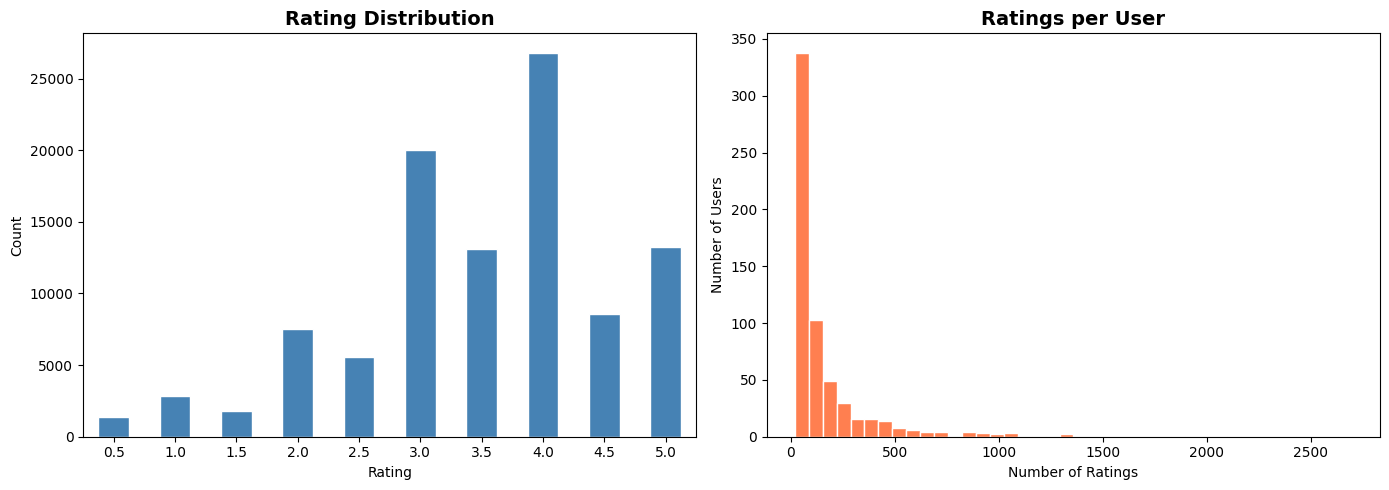

In [75]:
# ── 1. Rating Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
)
axes[0].set_title('Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

user_rating_counts = ratings.groupby('userId')['rating'].count()
axes[1].hist(user_rating_counts, bins=40, color='coral', edgecolor='white')
axes[1].set_title('Ratings per User', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

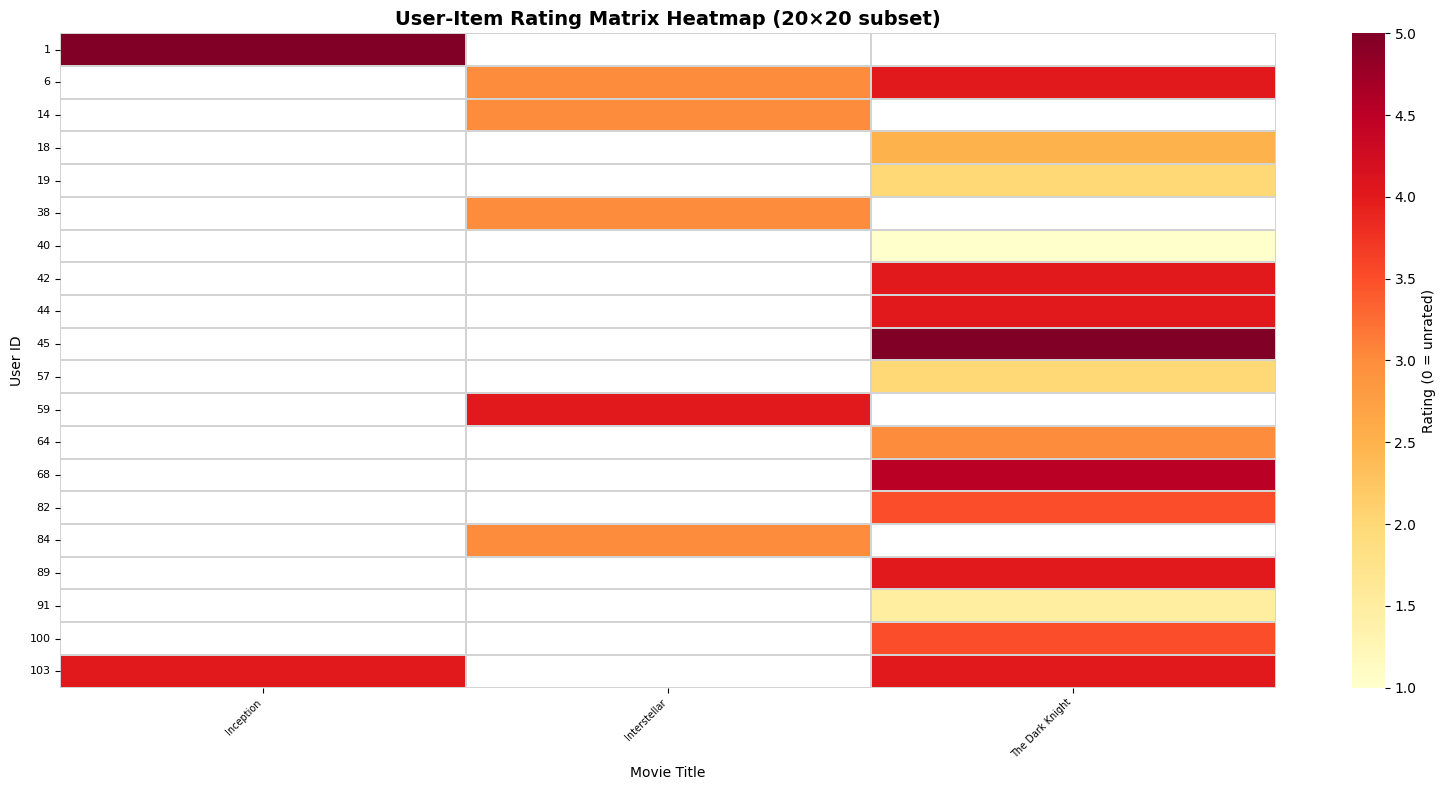

In [76]:
# ── 2. Heatmap of User-Item Matrix (subset)
subset = user_item_matrix.iloc[:20, :20]

plt.figure(figsize=(16, 8))
sns.heatmap(
    subset,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='lightgrey',
    annot=False,
    cbar_kws={'label': 'Rating (0 = unrated)'}
)
plt.title('User-Item Rating Matrix Heatmap (20×20 subset)', fontsize=14, fontweight='bold')
plt.xlabel('Movie Title')
plt.ylabel('User ID')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('user_item_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

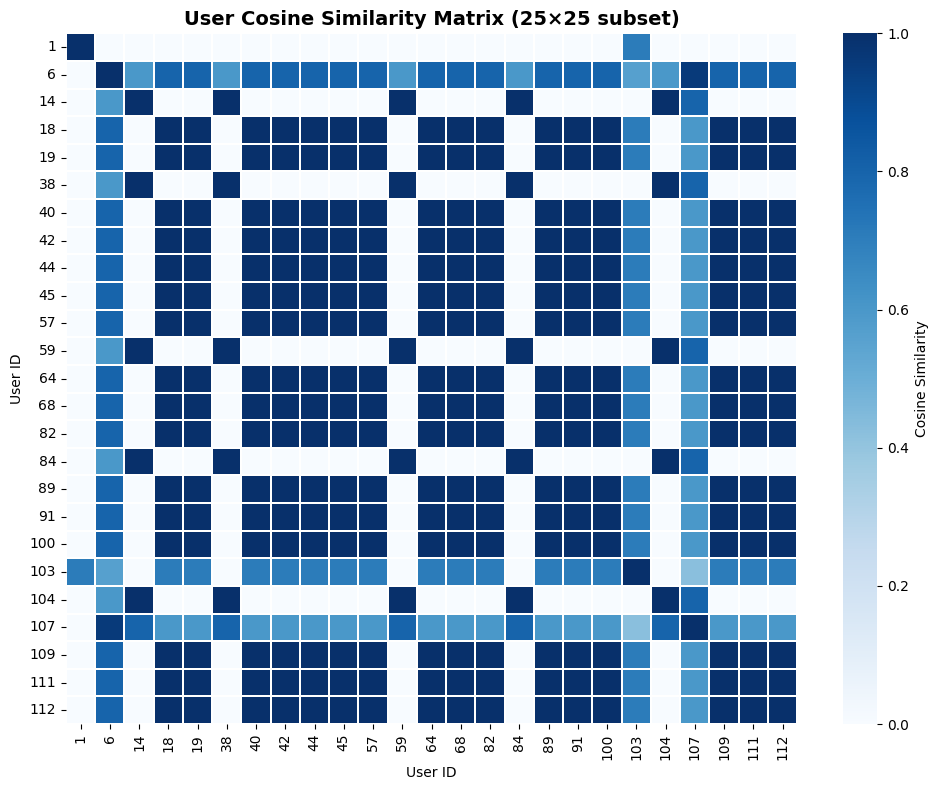

In [77]:
# ── 3. User Similarity Matrix Heatmap (subset)
sim_subset = user_similarity_df.iloc[:25, :25]

plt.figure(figsize=(10, 8))
sns.heatmap(
    sim_subset,
    cmap='Blues',
    linewidths=0.2,
    vmin=0, vmax=1,
    cbar_kws={'label': 'Cosine Similarity'}
)
plt.title('User Cosine Similarity Matrix (25×25 subset)', fontsize=14, fontweight='bold')
plt.xlabel('User ID')
plt.ylabel('User ID')
plt.tight_layout()
plt.savefig('user_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

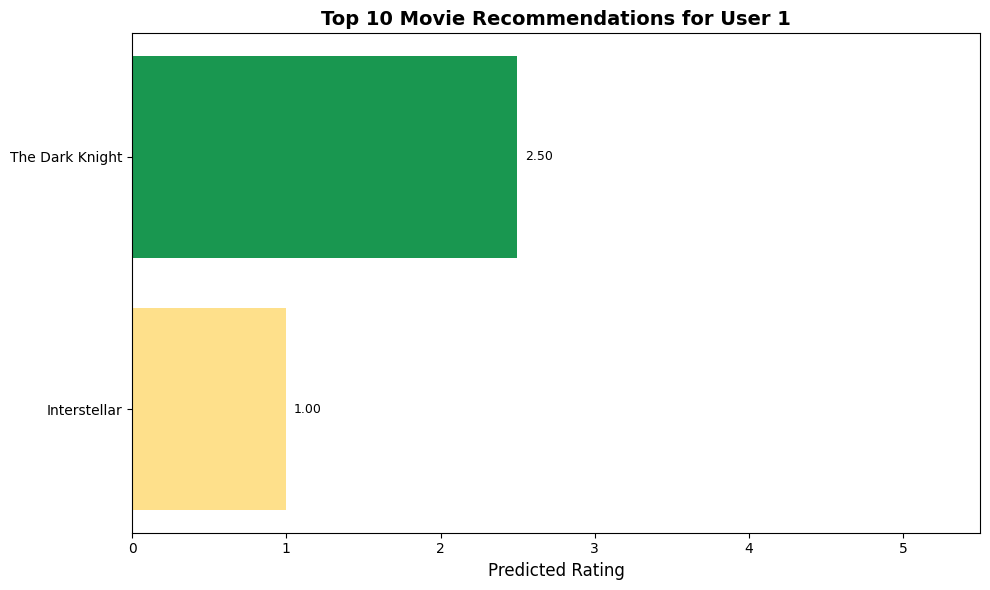

In [78]:
# ── 4. Top Recommended Movies for Target User
if recommendations:
    top_movies  = [r[0][:40] for r in recommendations[:10]]
    top_scores  = [r[1]       for r in recommendations[:10]]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(top_movies[::-1], top_scores[::-1],
                   color=plt.cm.RdYlGn(np.linspace(0.4, 0.9, len(top_movies))))
    ax.set_xlabel('Predicted Rating', fontsize=12)
    ax.set_title(f'Top 10 Movie Recommendations for User {TARGET_USER}',
                 fontsize=14, fontweight='bold')
    ax.set_xlim(0, 5.5)
    for bar, score in zip(bars, top_scores[::-1]):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{score:.2f}', va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('top_recommendations_user.png', dpi=150, bbox_inches='tight')
    plt.show()

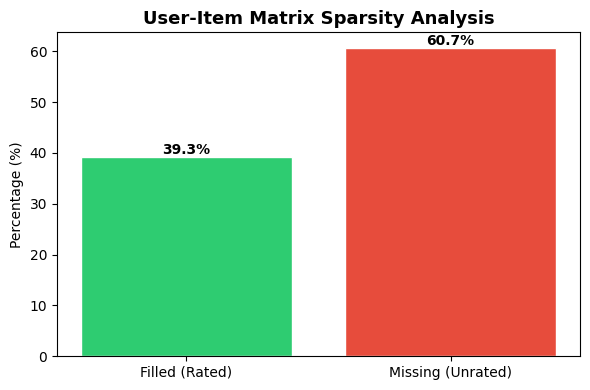

Matrix sparsity: 60.70%
This is typical for collaborative filtering datasets.


In [79]:
# ── 5. Sparsity Visual
filled_pct  = 100 - sparsity

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Filled (Rated)', 'Missing (Unrated)'], [filled_pct, sparsity],
       color=['#2ecc71', '#e74c3c'], edgecolor='white')
ax.set_title('User-Item Matrix Sparsity Analysis', fontsize=13, fontweight='bold')
ax.set_ylabel('Percentage (%)')
for i, v in enumerate([filled_pct, sparsity]):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('sparsity_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Matrix sparsity: {sparsity:.2f}%')
print(f'This is typical for collaborative filtering datasets.')